In [46]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import time
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    precision_recall_fscore_support,
    classification_report,
    pairwise_distances
)
from sklearn.metrics import pairwise_distances
np.random.seed(42)
torch.manual_seed(42)

In [24]:
X_train = np.load('../step1/X_train.npy')
X_val = np.load('../step1/X_val.npy')
X_test = np.load('../step1/X_test.npy')
y_train = np.load('../step1/y_train.npy')
y_val = np.load('../step1/y_val.npy')
y_test = np.load('../step1/y_test.npy')

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (2099, 13), Val: (450, 13), Test: (451, 13)


In [25]:
class RBFLayer(nn.Module):
    """
    لایه توابع پایه شعاعی (RBF)
    φ(x) = exp(-||x-c||² / (2σ²))
    """
    def __init__(self, num_inputs, num_centers, centers=None, sigma=1.0,
                 trainable_centers=False, trainable_sigma=False):
        super().__init__()
        self.num_centers = num_centers
        self.num_inputs = num_inputs

        if centers is None:
            centers = np.random.randn(num_centers, num_inputs) * 0.1

        self.centers = nn.Parameter(
            torch.tensor(centers, dtype=torch.float32),
            requires_grad=trainable_centers
        )

        if isinstance(sigma, (float, int)):
            sigma = np.full((num_centers,), sigma)

        self.sigma = nn.Parameter(
            torch.tensor(sigma, dtype=torch.float32),
            requires_grad=trainable_sigma
        )

    def forward(self, x):
        diff = x.unsqueeze(1) - self.centers.unsqueeze(0)
        distances_sq = torch.sum(diff ** 2, dim=2)
        out = torch.exp(-distances_sq / (2 * self.sigma.unsqueeze(0) ** 2))
        return out

print(" لایه RBF ساخته شد")

 لایه RBF ساخته شد


In [26]:
class RBFNetwork(nn.Module):
    """
    شبکه RBF با:
    - لایه ورودی
    - لایه پنهان RBF
    - لایه خروجی خطی (برای logits)
    """
    def __init__(self, num_inputs, num_centers, num_classes=3,
                 centers=None, sigma=1.0,
                 trainable_centers=False, trainable_sigma=False):
        super().__init__()
        self.rbf = RBFLayer(num_inputs, num_centers, centers, sigma,
                            trainable_centers, trainable_sigma)
        self.output_layer = nn.Linear(num_centers, num_classes)

    def forward(self, x):
        h = self.rbf(x)
        logits = self.output_layer(h)
        return logits

print(" شبکه RBF ساخته شد")

 شبکه RBF ساخته شد


In [27]:
from torch.utils.data import DataLoader, TensorDataset

def initialize_centers_kmeans(X_train, num_centers):
    """مقداردهی مراکز با الگوریتم K-Means"""
    kmeans = KMeans(n_clusters=num_centers, random_state=42, n_init=10)
    kmeans.fit(X_train)
    return kmeans.cluster_centers_

def initialize_centers_random(X_train, num_centers):
    """مقداردهی تصادفی مراکز از داده‌های آموزش """
    indices = np.random.choice(len(X_train), num_centers, replace=False)
    return X_train[indices]

def train_rbf(model, X_train, y_train, X_val, y_val, epochs=150, lr=0.01,
              batch_size=32, patience=15, verbose=True):
    """آموزش مدل RBF """
    start_time = time.time()

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # تبدیل به tensor
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.long)

    # DataLoader برای Mini-Batch
    train_dataset = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    history = {'train_loss': [], 'val_loss': [], 'val_f1': []}
    best_val_f1 = 0
    best_state = None
    epochs_no_improve = 0

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_train_loss = epoch_loss / len(train_loader)

        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_t)
            val_loss = criterion(val_outputs, y_val_t)
            val_pred = torch.argmax(val_outputs, dim=1).numpy()
            val_f1 = f1_score(y_val, val_pred, average='macro')

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss.item())
        history['val_f1'].append(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if verbose and (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_train_loss:.4f} | Val Loss: {val_loss.item():.4f} | Val F1: {val_f1:.4f}")

        if epochs_no_improve >= patience:
            if verbose:
                print(f" Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(best_state)
    training_time = time.time() - start_time
    return history, best_val_f1, training_time

print(" توابع کمکی تعریف شدند")

 توابع کمکی تعریف شدند


In [38]:
#تعداد مراکز و روش مقدار دهی
results = []
# ========== تابع تولید مراکز ==========
def get_centers(method, n, X):
    if method == 'k-means':
        return initialize_centers_kmeans(X, n)
    elif method == 'random_from_data':
        return initialize_centers_random(X, n)
    else:
        return np.random.randn(n, X.shape[1]) * 0.1
# ========== تنظیمات آزمایش‌ها ==========
centers_options = [50, 100, 200, 300]
init_methods = ['k-means', 'random_from_data', 'random_normal']
init_desc = {'k-means': 'K-Means', 'random_from_data': 'Random from data', 'random_normal': 'Random normal'}
# نتایج برای جدول
experiments_results = []

for n_centers in centers_options:
    for init_key in init_methods:
        print(f"\n--- آزمایش: {n_centers} مرکز - روش مقداردهی: {init_desc[init_key]} ---")

        centers = get_centers(init_key, n_centers, X_train)

        model = RBFNetwork(
            num_inputs=X_train.shape[1],
            num_centers=n_centers,
            num_classes=3,
            centers=centers,
            sigma=1.0,
            trainable_centers=False,
            trainable_sigma=False
        )

        history, val_f1, training_time = train_rbf(
            model, X_train, y_train, X_val, y_val,
            epochs=150, lr=0.01, batch_size=32, patience=15, verbose=True
        )

        experiments_results.append({
            'تعداد_مراکز': n_centers,
            'روش_مقداردهی': init_desc[init_key],
            'روش_مقداردهی_کلید': init_key,
            'Macro-F1': val_f1,
            'زمان_آموزش': training_time
        })

# ========== نمایش جدول نتائج ==========
print("\n" + "=" * 80)
print("جدول نتایج آزمایش‌های RBF")
print("=" * 80)

df_results = pd.DataFrame(experiments_results)
print(df_results.to_string(index=False))

# بهترین تنظیمات از آزمایش اول
best_idx = df_results['Macro-F1'].idxmax()
best_n_centers = df_results.loc[best_idx, 'تعداد_مراکز']
best_init = df_results.loc[best_idx, 'روش_مقداردهی']
best_init_key = df_results.loc[best_idx, 'روش_مقداردهی_کلید']

print(f"\n بهترین تنظیمات از آزمایش اول:")
print(f"   تعداد مراکز: {best_n_centers}")
print(f"   روش مقداردهی: {best_init}")


--- آزمایش: 50 مرکز - روش مقداردهی: K-Means ---
Epoch 20/150 | Loss: 0.6399 | Val Loss: 0.6531 | Val F1: 0.7360
Epoch 40/150 | Loss: 0.6063 | Val Loss: 0.6204 | Val F1: 0.7437
Epoch 60/150 | Loss: 0.5903 | Val Loss: 0.6108 | Val F1: 0.7473
 Early stopping at epoch 69

--- آزمایش: 50 مرکز - روش مقداردهی: Random from data ---
Epoch 20/150 | Loss: 0.7207 | Val Loss: 0.7411 | Val F1: 0.6732
Epoch 40/150 | Loss: 0.6741 | Val Loss: 0.7015 | Val F1: 0.6772
 Early stopping at epoch 57

--- آزمایش: 50 مرکز - روش مقداردهی: Random normal ---
Epoch 20/150 | Loss: 0.9003 | Val Loss: 0.9090 | Val F1: 0.4804
Epoch 40/150 | Loss: 0.8712 | Val Loss: 0.8820 | Val F1: 0.5241
Epoch 60/150 | Loss: 0.8566 | Val Loss: 0.8669 | Val F1: 0.5745
 Early stopping at epoch 75

--- آزمایش: 100 مرکز - روش مقداردهی: K-Means ---
Epoch 20/150 | Loss: 0.5663 | Val Loss: 0.6088 | Val F1: 0.7419
Epoch 40/150 | Loss: 0.5250 | Val Loss: 0.5899 | Val F1: 0.7338
 Early stopping at epoch 49

--- آزمایش: 100 مرکز - روش مقداردهی

In [39]:
print("\n" + "=" * 80)
print("آزمایش: Trainable Centers vs Fixed Centers")
print("=" * 80)

centers = get_centers(best_init_key, best_n_centers, X_train)

best_trainable_centers = False
best_f1 = -1

for trainable in [False, True]:
    desc = "قابل آموزش" if trainable else "ثابت"
    print(f"\n--- آزمایش: مراکز {desc} ---")

    model = RBFNetwork(
        num_inputs=X_train.shape[1],
        num_centers=best_n_centers,
        num_classes=3,
        centers=centers.copy(),
        sigma=1.0,
        trainable_centers=trainable,
        trainable_sigma=False
    )

    history, val_f1, training_time = train_rbf(
        model, X_train, y_train, X_val, y_val,
        epochs=150, lr=0.01, batch_size=32, patience=15, verbose=True
    )

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_trainable_centers = trainable

    print(f" F1: {val_f1:.4f}")

print(f"\n بهترین حالت آموزش مراکز: {'قابل آموزش' if best_trainable_centers else 'ثابت'}")


آزمایش: Trainable Centers vs Fixed Centers

--- آزمایش: مراکز ثابت ---
Epoch 20/150 | Loss: 0.3979 | Val Loss: 0.4811 | Val F1: 0.7976
Epoch 40/150 | Loss: 0.3390 | Val Loss: 0.4490 | Val F1: 0.8091
Epoch 60/150 | Loss: 0.3136 | Val Loss: 0.4401 | Val F1: 0.8144
Epoch 80/150 | Loss: 0.2980 | Val Loss: 0.4396 | Val F1: 0.8129
 Early stopping at epoch 89
 F1: 0.8211

--- آزمایش: مراکز قابل آموزش ---
Epoch 20/150 | Loss: 0.2595 | Val Loss: 0.4323 | Val F1: 0.8271
Epoch 40/150 | Loss: 0.1623 | Val Loss: 0.4359 | Val F1: 0.8381
Epoch 60/150 | Loss: 0.1121 | Val Loss: 0.4685 | Val F1: 0.8343
 Early stopping at epoch 67
 F1: 0.8533

 بهترین حالت آموزش مراکز: قابل آموزش


In [40]:
print("\n" + "=" * 80)
print("آزمایش: Trainable Sigma vs Fixed Sigma")
print("=" * 80)

centers = get_centers(best_init_key, best_n_centers, X_train)

best_trainable_sigma = False
best_f1 = -1

for trainable_sigma in [False, True]:
    desc = "قابل آموزش" if trainable_sigma else "ثابت"
    print(f"\n--- آزمایش: شعاع {desc} ---")

    model = RBFNetwork(
        num_inputs=X_train.shape[1],
        num_centers=best_n_centers,
        num_classes=3,
        centers=centers.copy(),
        sigma=1.0,
        trainable_centers=best_trainable_centers,
        trainable_sigma=trainable_sigma
    )

    history, val_f1, training_time = train_rbf(
        model, X_train, y_train, X_val, y_val,
        epochs=150, lr=0.01, batch_size=32, patience=15, verbose=True
    )

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_trainable_sigma = trainable_sigma

    print(f" F1: {val_f1:.4f}")

print(f"\n بهترین حالت آموزش شعاع: {'قابل آموزش' if best_trainable_sigma else 'ثابت'}")


آزمایش: Trainable Sigma vs Fixed Sigma

--- آزمایش: شعاع ثابت ---
Epoch 20/150 | Loss: 0.2581 | Val Loss: 0.4385 | Val F1: 0.8130
Epoch 40/150 | Loss: 0.1606 | Val Loss: 0.4407 | Val F1: 0.8385
Epoch 60/150 | Loss: 0.1120 | Val Loss: 0.4632 | Val F1: 0.8310
 Early stopping at epoch 76
 F1: 0.8492

--- آزمایش: شعاع قابل آموزش ---
Epoch 20/150 | Loss: 0.2304 | Val Loss: 0.3382 | Val F1: 0.8606
 Early stopping at epoch 31
 F1: 0.8953

 بهترین حالت آموزش شعاع: قابل آموزش


In [31]:
print("\n" + "=" * 80)
print("آزمایش: Trainable Centers + Trainable Sigma (هر دو با هم)")
print("=" * 80)

centers = get_centers('k-means', best_n_centers, X_train)

model = RBFNetwork(
    num_inputs=X_train.shape[1],
    num_centers=best_n_centers,
    num_classes=3,
    centers=centers,
    sigma=1.0,
    trainable_centers=True,   # مراکز آموزش می‌بینند
    trainable_sigma=True       # شعاع‌ها آموزش می‌بینند
)

history, val_f1, training_time = train_rbf(
    model, X_train, y_train, X_val, y_val,
    epochs=150, lr=0.01, batch_size=32, patience=15, verbose=True
)

print(f" F1 (هر دو قابل آموزش): {val_f1:.4f}")

# ذخیره نتیجه برای مقایسه
results.append({
    'تعداد_مراکز': best_n_centers,
    'روش_مقداردهی': 'k-means',
    'آموزش_مراکز': 'قابل آموزش',
    'آموزش_شعاع': 'قابل آموزش',
    'نرخ_یادگیری': 0.01,
    'Macro-F1': val_f1,
    'زمان_آموزش': training_time
})


آزمایش: Trainable Centers + Trainable Sigma (هر دو با هم)
Epoch 20/150 | Loss: 0.2447 | Val Loss: 0.3361 | Val F1: 0.8654
 Early stopping at epoch 30
 F1 (هر دو قابل آموزش): 0.8976


In [42]:
print("\n" + "=" * 80)
print("آزمایش: محاسبه Sigma از فاصله مراکز")
print("=" * 80)

centers = get_centers(best_init_key, best_n_centers, X_train)

dist = pairwise_distances(centers)
np.fill_diagonal(dist, np.inf)
min_distances = np.min(dist, axis=1)
sigma_from_dist = np.mean(min_distances)

print(f"محاسبه شد: sigma = {sigma_from_dist:.4f}")

model = RBFNetwork(
    num_inputs=X_train.shape[1],
    num_centers=best_n_centers,
    num_classes=3,
    centers=centers,
    sigma=sigma_from_dist,
    trainable_centers=best_trainable_centers,
    trainable_sigma=best_trainable_sigma
)

history, val_f1, training_time = train_rbf(
    model, X_train, y_train, X_val, y_val,
    epochs=150, lr=0.01, batch_size=32, patience=15, verbose=True
)

best_sigma = sigma_from_dist

print(f" F1 با sigma از فاصله مراکز: {val_f1:.4f}")
print(f" بهترین Sigma: {best_sigma:.4f}")


آزمایش: محاسبه Sigma از فاصله مراکز
محاسبه شد: sigma = 1.9132
Epoch 20/150 | Loss: 0.2568 | Val Loss: 0.2996 | Val F1: 0.8848
Epoch 40/150 | Loss: 0.2227 | Val Loss: 0.3105 | Val F1: 0.8730
 Early stopping at epoch 43
 F1 با sigma از فاصله مراکز: 0.8974
 بهترین Sigma: 1.9132


In [35]:
print("\n" + "=" * 80)
print("آزمایش: نرخ یادگیری و Batch Size")
print("=" * 80)

centers = get_centers('k-means', best_n_centers, X_train)

# آزمایش نرخ یادگیری
learning_rates = [0.001, 0.005, 0.01, 0.05]
lr_results = []

for lr in learning_rates:
    print(f"\n--- آزمایش: lr = {lr} ---")

    model = RBFNetwork(
        num_inputs=X_train.shape[1],
        num_centers=best_n_centers,
        num_classes=3,
        centers=centers.copy(),
        sigma=1.0,
        trainable_centers=False,
        trainable_sigma=False
    )

    _, val_f1, _ = train_rbf(
        model, X_train, y_train, X_val, y_val,
        epochs=150, lr=lr, batch_size=32, patience=15, verbose=True
    )

    lr_results.append({'نرخ_یادگیری': lr, 'Macro-F1': val_f1})

best_lr = max(lr_results, key=lambda x: x['Macro-F1'])['نرخ_یادگیری']
print(f"\n بهترین نرخ یادگیری: {best_lr}")

# آزمایش Batch Size
batch_sizes = [16, 32, 64, 128]
bs_results = []

for bs in batch_sizes:
    print(f"\n--- آزمایش: batch_size = {bs} ---")

    model = RBFNetwork(
        num_inputs=X_train.shape[1],
        num_centers=best_n_centers,
        num_classes=3,
        centers=centers.copy(),
        sigma=1.0,
        trainable_centers=False,
        trainable_sigma=False
    )

    _, val_f1, _ = train_rbf(
        model, X_train, y_train, X_val, y_val,
        epochs=150, lr=best_lr, batch_size=bs, patience=15, verbose=True
    )

    bs_results.append({'batch_size': bs, 'Macro-F1': val_f1})

best_bs = max(bs_results, key=lambda x: x['Macro-F1'])['batch_size']
print(f"\n بهترین Batch Size: {best_bs}")


آزمایش: نرخ یادگیری و Batch Size

--- آزمایش: lr = 0.001 ---
Epoch 20/150 | Loss: 0.6717 | Val Loss: 0.6992 | Val F1: 0.7272
Epoch 40/150 | Loss: 0.5707 | Val Loss: 0.6139 | Val F1: 0.7667
 Early stopping at epoch 48

--- آزمایش: lr = 0.005 ---
Epoch 20/150 | Loss: 0.4665 | Val Loss: 0.5295 | Val F1: 0.7781
Epoch 40/150 | Loss: 0.3926 | Val Loss: 0.4797 | Val F1: 0.7979
Epoch 60/150 | Loss: 0.3559 | Val Loss: 0.4586 | Val F1: 0.8043
 Early stopping at epoch 72

--- آزمایش: lr = 0.01 ---
Epoch 20/150 | Loss: 0.3986 | Val Loss: 0.4815 | Val F1: 0.8011
Epoch 40/150 | Loss: 0.3400 | Val Loss: 0.4505 | Val F1: 0.8087
Epoch 60/150 | Loss: 0.3145 | Val Loss: 0.4392 | Val F1: 0.8123
Epoch 80/150 | Loss: 0.2982 | Val Loss: 0.4390 | Val F1: 0.8129
 Early stopping at epoch 97

--- آزمایش: lr = 0.05 ---
Epoch 20/150 | Loss: 0.3088 | Val Loss: 0.4349 | Val F1: 0.8189
Epoch 40/150 | Loss: 0.2817 | Val Loss: 0.4632 | Val F1: 0.8076
 Early stopping at epoch 41

 بهترین نرخ یادگیری: 0.05

--- آزمایش: 

In [44]:
print("\n" + "=" * 80)
print("آموزش مدل نهایی با بهترین تنظیمات")
print("=" * 80)

# بهترین تنظیمات (همه از متغیرهای بهینه)
best_config = {
    'num_centers': best_n_centers,
    'init_key': best_init_key,
    'sigma': best_sigma,
    'lr': best_lr,
    'batch_size': best_bs,
    'trainable_centers': best_trainable_centers,
    'trainable_sigma': best_trainable_sigma
}

print(f"بهترین تنظیمات:")
for k, v in best_config.items():
    print(f"  {k}: {v}")

# تولید مراکز با بهترین روش مقداردهی
centers = get_centers(best_config['init_key'], best_config['num_centers'], X_train)

# ساخت مدل نهایی
final_model = RBFNetwork(
    num_inputs=X_train.shape[1],
    num_centers=best_config['num_centers'],
    num_classes=3,
    centers=centers,
    sigma=best_config['sigma'],
    trainable_centers=best_config['trainable_centers'],
    trainable_sigma=best_config['trainable_sigma']
)

start_time = time.time()
history, best_val_f1, _ = train_rbf(
    final_model, X_train, y_train, X_val, y_val,
    epochs=200, lr=best_config['lr'], batch_size=best_config['batch_size'],
    patience=15, verbose=True
)
train_time = time.time() - start_time

print(f"\n زمان آموزش مدل نهایی: {train_time:.2f} ثانیه")
print(f" بهترین F1 اعتبارسنجی: {best_val_f1:.4f}")


آموزش مدل نهایی با بهترین تنظیمات
بهترین تنظیمات:
  num_centers: 300
  init_key: k-means
  sigma: 1.913228324968317
  lr: 0.05
  batch_size: 16
  trainable_centers: True
  trainable_sigma: True
Epoch 20/200 | Loss: 0.3548 | Val Loss: 0.4310 | Val F1: 0.7533
 Early stopping at epoch 31

 زمان آموزش مدل نهایی: 15.13 ثانیه
 بهترین F1 اعتبارسنجی: 0.8660


In [47]:
print("\n" + "=" * 70)
print("ارزیابی نهایی مدل RBF روی داده‌های تست")
print("=" * 70)

final_model.eval()
X_test_t = torch.tensor(X_test, dtype=torch.float32)

with torch.no_grad():
    test_outputs = final_model(X_test_t)
    y_pred = torch.argmax(test_outputs, dim=1).numpy()

# ========== محاسبه همه معیارهای خواسته شده (بخش 1.7) ==========
test_acc = accuracy_score(y_test, y_pred)
test_macro_f1 = f1_score(y_test, y_pred, average='macro')
test_weighted_f1 = f1_score(y_test, y_pred, average='weighted')

precision, recall, f1_per_class, _ = precision_recall_fscore_support(y_test, y_pred, average=None)

print("\n معیارهای ارزیابی (بخش 1.7 مستند):")
print(f" Accuracy: {test_acc:.4f}")
print(f" Macro-F1: {test_macro_f1:.4f}")
print(f" Weighted-F1: {test_weighted_f1:.4f}")

print("\n گزارش هر کلاس (Precision, Recall, F1-score):")
class_names = ['Good', 'Acceptable', 'Poor']
print("کلاس | Precision | Recall | F1-score")
print("-----|-----------|--------|---------")
for i, name in enumerate(class_names):
    print(f"{name:6} | {precision[i]:.4f}    | {recall[i]:.4f}  | {f1_per_class[i]:.4f}")

print("\n ماتریس درهم‌ریختگی (Confusion Matrix):")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\n گزارش کامل classification_report:")
print(classification_report(y_test, y_pred, target_names=class_names))


ارزیابی نهایی مدل RBF روی داده‌های تست

 معیارهای ارزیابی (بخش 1.7 مستند):
 Accuracy: 0.8293
 Macro-F1: 0.8295
 Weighted-F1: 0.8288

 گزارش هر کلاس (Precision, Recall, F1-score):
کلاس | Precision | Recall | F1-score
-----|-----------|--------|---------
Good   | 0.8318    | 0.7876  | 0.8091
Acceptable | 0.8402    | 0.8142  | 0.8270
Poor   | 0.8080    | 0.9018  | 0.8523

 ماتریس درهم‌ریختگی (Confusion Matrix):
[[ 89  24   0]
 [ 18 184  24]
 [  0  11 101]]

 گزارش کامل classification_report:
              precision    recall  f1-score   support

        Good       0.83      0.79      0.81       113
  Acceptable       0.84      0.81      0.83       226
        Poor       0.81      0.90      0.85       112

    accuracy                           0.83       451
   macro avg       0.83      0.83      0.83       451
weighted avg       0.83      0.83      0.83       451



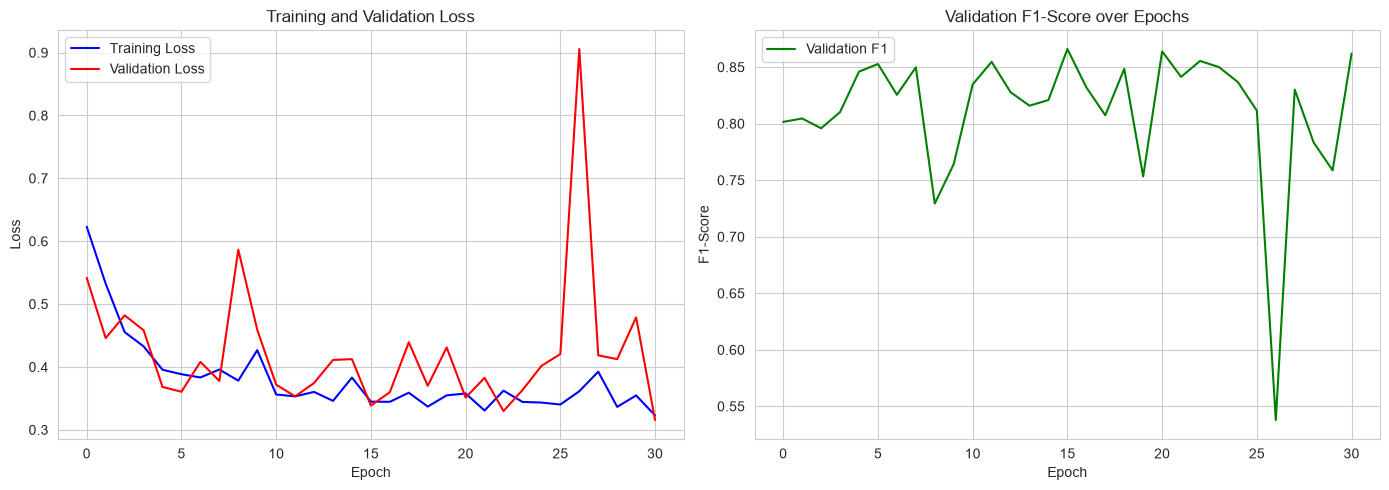

 نمودارها ذخیره شدند


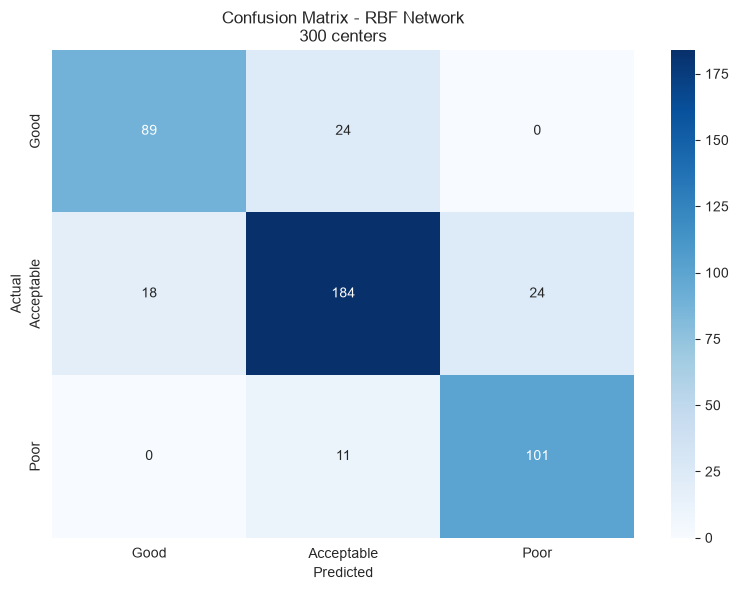

 ماتریس درهم‌ریختگی ذخیره شد


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# نمودار Loss
axes[0].plot(history['train_loss'], label='Training Loss', color='blue')
axes[0].plot(history['val_loss'], label='Validation Loss', color='red')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# نمودار F1
axes[1].plot(history['val_f1'], label='Validation F1', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1-Score')
axes[1].set_title('Validation F1-Score over Epochs')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('rbf_training_curves.png', dpi=150)
plt.show()
print(" نمودارها ذخیره شدند")

# ماتریس درهم‌ریختگی
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - RBF Network\n{best_n_centers} centers')
plt.tight_layout()
plt.savefig('rbf_confusion_matrix.png', dpi=150)
plt.show()
print(" ماتریس درهم‌ریختگی ذخیره شد")

In [49]:
torch.save(final_model.state_dict(), 'best_rbf_model.pth')
print(" مدل نهایی ذخیره شد: best_rbf_model.pth")

 مدل نهایی ذخیره شد: best_rbf_model.pth
